## Example of Slow-Fast response

## $\frac{dy}{dt} = 2(1-y)-ye^{-4t}$

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# slow and fast response 

##### ODE in a function + Initial Condition #####
y0 = 5
def f(y,t):
    return -2*y - np.exp(-4*t)  

## using RK4 and Euler forward method 

In [50]:
##### Independent Variable Discretization #####
points = 100
t = np.linspace(0,2,points)
##### Step Size Calculation #####
h = t[2]-t[1]


##### Euler's Method #####
def Euler_method(f,y0,t):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(0,len(t)-1):
        y[i+1] = y[i] + f(y[i],t[i])*(t[i+1]-t[i])
    return y
    
y_Euler = Euler_method(f,y0,t)


##### Runge Kutta 4th Order Method #####
def RK_method(f,y0,t):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(0,len(t)-1):
        h = t[i+1]-t[i]
        F1 = h*f(y[i],t[i])
        F2 = h*f((y[i]+F1/2),(t[i]+h/2))
        F3 = h*f((y[i]+F2/2),(t[i]+h/2))
        F4 = h*f((y[i]+F3),(t[i]+h))
        y[i+1] = y[i] + 1/6*(F1 + 2*F2 + 2*F3 + F4)
    return y
y_RK = RK_method(f,y0,t)

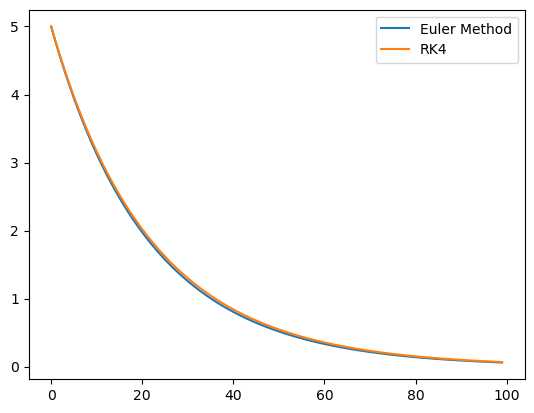

In [51]:
plt.plot(y_Euler,label='Euler Method')
plt.plot(y_RK,label='RK4')
plt.legend()

## add external forcing, u(t), to the system 

## $y^{"}+2y^{'}+y=u(t)$

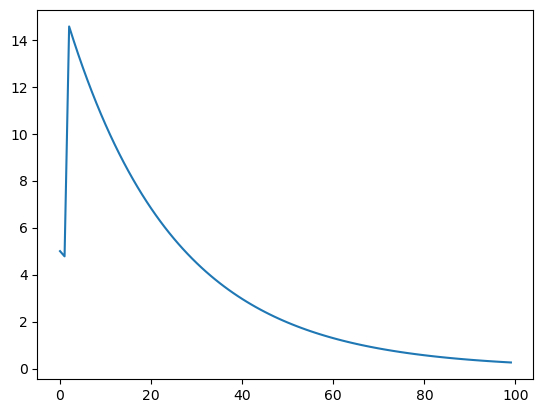

In [55]:
##### Independent Variable Discretization #####
points = 100
t = np.linspace(0,2,points)
##### Step Size Calculation #####
h = t[2]-t[1]


##### Euler's Method #####
def Euler_method_with_forcing(f,y0,t,G):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(0,len(t)-1):
        y[i+1] = y[i] + f(y[i],t[i])*(t[i+1]-t[i])+G[i]
    return y

G       = np.zeros((100))
#G[:]    = 1
G[1]    = 10
y_Euler = Euler_method_with_forcing(f,y0,t,G)

plt.plot(y_Euler)